# Notebook 04 — Channel Attribution Analysis

*Project:* GA4 + GTM Analytics — Google Merchandise Store  
*Analyst:* Philip Ocheri  
*Notebook Purpose:* Analyse traffic source and channel performance, device breakdown, and revenue attribution across mediums to inform marketing spend decisions.

---

## 1. Load Channel & Device Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/ga_sessions_2017_channel_device.csv')
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nUnique mediums: {df['medium'].unique()}")
print(f"Unique devices: {df['device'].unique()}")
df.head(10)

Shape: (10846, 8)
Columns: ['date', 'medium', 'source', 'device', 'sessions', 'transactions', 'revenue', 'bounces']

Unique mediums: ['cpc' 'organic' '(none)' 'referral' 'affiliate' 'cpm' '(not set)']
Unique devices: ['tablet' 'desktop' 'mobile']


,date,medium,source,device,sessions,transactions,revenue,bounces
0,2017-01-01,cpc,google,tablet,9,NaN,NaN,3.0
1,2017-01-01,organic,google,desktop,312,5.0,180.90,134.0
2,2017-01-01,(none),(direct),desktop,154,6.0,812.11,57.0
3,2017-01-01,(none),(direct),tablet,17,NaN,NaN,10.0
4,2017-01-01,organic,google,tablet,57,NaN,NaN,28.0
5,2017-01-01,referral,reddit.com,desktop,1,NaN,NaN,1.0
6,2017-01-01,(none),(direct),mobile,118,NaN,NaN,67.0
7,2017-01-01,referral,siliconvalley.about.com,desktop,5,NaN,NaN,NaN
8,2017-01-01,referral,youtube.com,mobile,50,NaN,NaN,32.0
9,2017-01-01,referral,analytics.google.com,desktop,11,NaN,NaN,2.0


## 2. Channel Performance by Medium

In [2]:
# Aggregate by medium
medium = df.groupby('medium').agg(
    total_sessions   = ('sessions', 'sum'),
    total_transactions=('transactions', 'sum'),
    total_revenue    = ('revenue', 'sum'),
    total_bounces    = ('bounces', 'sum')
).reset_index()

medium['conversion_rate'] = (medium['total_transactions'] / medium['total_sessions']) * 100
medium['bounce_rate']     = (medium['total_bounces'] / medium['total_sessions']) * 100
medium['avg_order_value'] = medium['total_revenue'] / medium['total_transactions'].replace(0, np.nan)
medium['revenue_share']   = (medium['total_revenue'] / medium['total_revenue'].sum()) * 100

medium = medium.sort_values('total_revenue', ascending=False)

print("=== CHANNEL PERFORMANCE BY MEDIUM ===")
print(medium[['medium','total_sessions','total_revenue',
              'conversion_rate','avg_order_value',
              'revenue_share']].to_string(index=False))

=== CHANNEL PERFORMANCE BY MEDIUM ===
   medium  total_sessions  total_revenue  conversion_rate  avg_order_value  revenue_share
   (none)          189445      716676.81         2.479348       152.581820      69.652825
  organic          173428      146596.91         0.862606        97.992587      14.247550
      cpm            3226      121005.71         2.789833      1344.507889      11.760377
 referral           82023       23344.29         0.219451       129.690500       2.268799
      cpc            9265       20732.75         1.899622       117.799716       2.014987
affiliate            9761         558.67         0.061469        93.111667       0.054296
(not set)             112          11.99         0.892857        11.990000       0.001165


## 3. Revenue by Medium Chart

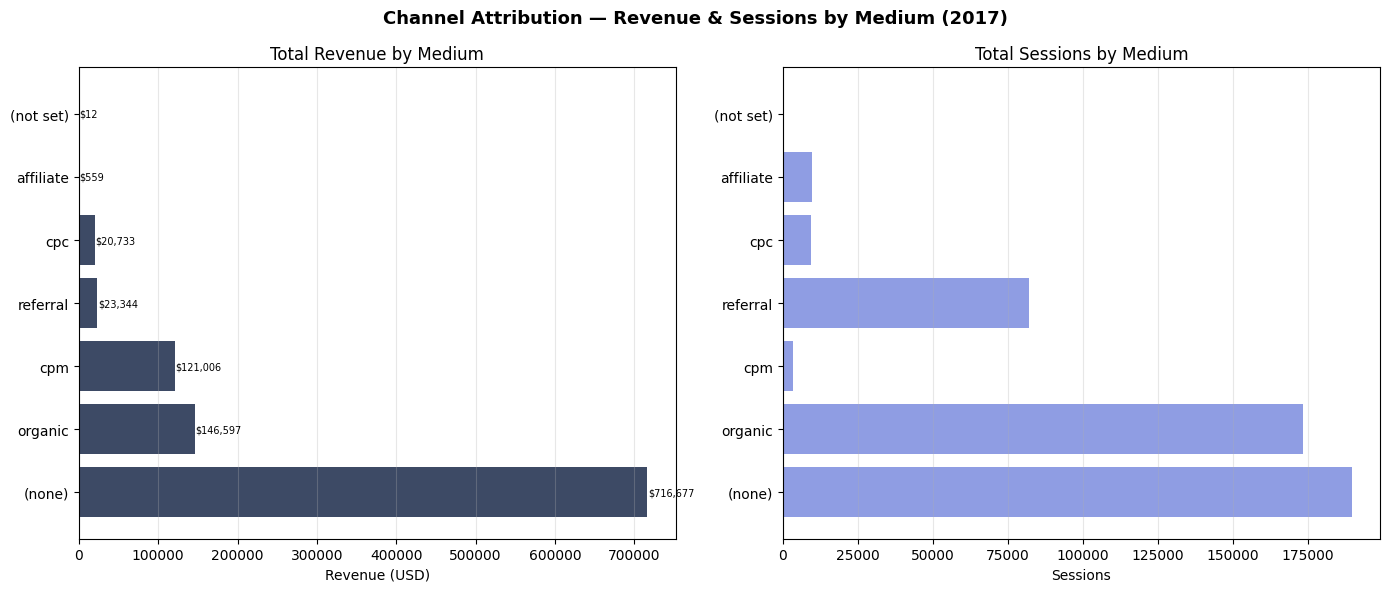

Chart saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Channel Attribution — Revenue & Sessions by Medium (2017)',
             fontsize=13, fontweight='bold')

# Revenue by medium
top_medium = medium.head(8)
axes[0].barh(top_medium['medium'], top_medium['total_revenue'],
             color='#1B2A4A', alpha=0.85)
axes[0].set_xlabel('Revenue (USD)')
axes[0].set_title('Total Revenue by Medium')
axes[0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(top_medium['total_revenue']):
    axes[0].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=7)

# Sessions by medium
axes[1].barh(top_medium['medium'], top_medium['total_sessions'],
             color='#7B8CDE', alpha=0.85)
axes[1].set_xlabel('Sessions')
axes[1].set_title('Total Sessions by Medium')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../reports/04_revenue_by_medium.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 4. Device Category Breakdown

In [4]:
# Aggregate by device
device = df.groupby('device').agg(
    total_sessions    = ('sessions', 'sum'),
    total_transactions= ('transactions', 'sum'),
    total_revenue     = ('revenue', 'sum'),
    total_bounces     = ('bounces', 'sum')
).reset_index()

device['conversion_rate'] = (device['total_transactions'] / device['total_sessions']) * 100
device['revenue_share']   = (device['total_revenue'] / device['total_revenue'].sum()) * 100
device['bounce_rate']     = (device['total_bounces'] / device['total_sessions']) * 100

print("=== DEVICE PERFORMANCE ===")
print(device[['device','total_sessions','total_revenue',
              'conversion_rate','revenue_share',
              'bounce_rate']].to_string(index=False))

=== DEVICE PERFORMANCE ===
 device  total_sessions  total_revenue  conversion_rate  revenue_share  bounce_rate
desktop          314707      992034.77         1.925918      96.414483    48.216595
 mobile          134032       32662.64         0.381252       3.174437    53.987854
 tablet           18521        4229.72         0.399546       0.411081    51.336321


## 5. Device Revenue & Conversion Chart

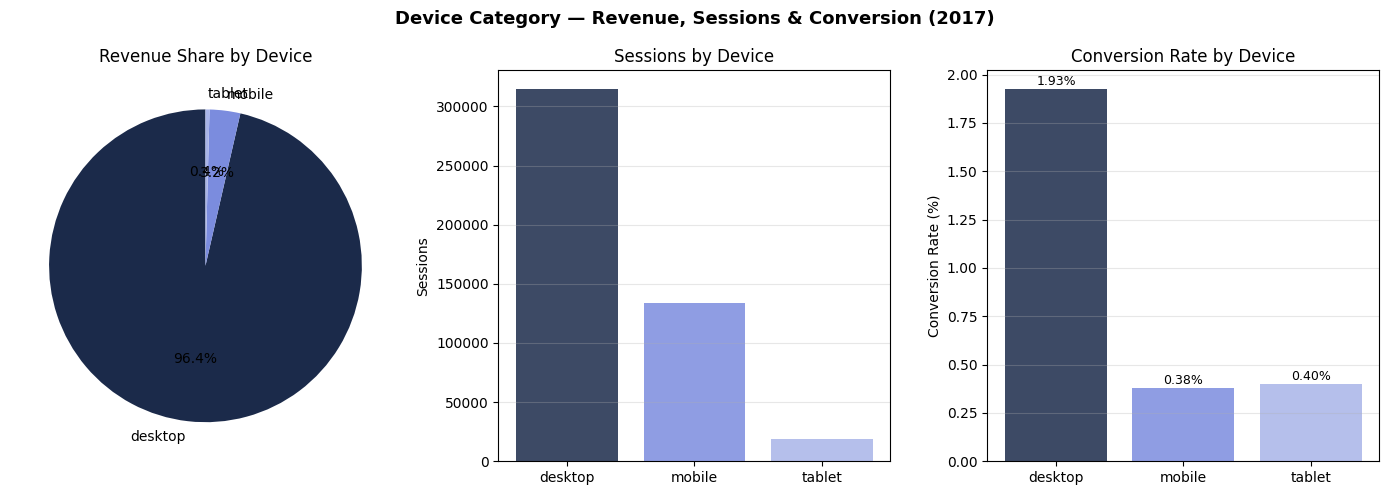

Chart saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Device Category — Revenue, Sessions & Conversion (2017)',
             fontsize=13, fontweight='bold')

colors = ['#1B2A4A', '#7B8CDE', '#A8B4E8']

# Revenue pie
axes[0].pie(device['total_revenue'], labels=device['device'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Revenue Share by Device')

# Sessions bar
axes[1].bar(device['device'], device['total_sessions'],
            color=colors, alpha=0.85)
axes[1].set_title('Sessions by Device')
axes[1].set_ylabel('Sessions')
axes[1].grid(True, alpha=0.3, axis='y')

# Conversion rate bar
axes[2].bar(device['device'], device['conversion_rate'],
            color=colors, alpha=0.85)
axes[2].set_title('Conversion Rate by Device')
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(device['conversion_rate']):
    axes[2].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/04_device_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 6. Top Traffic Sources by Revenue

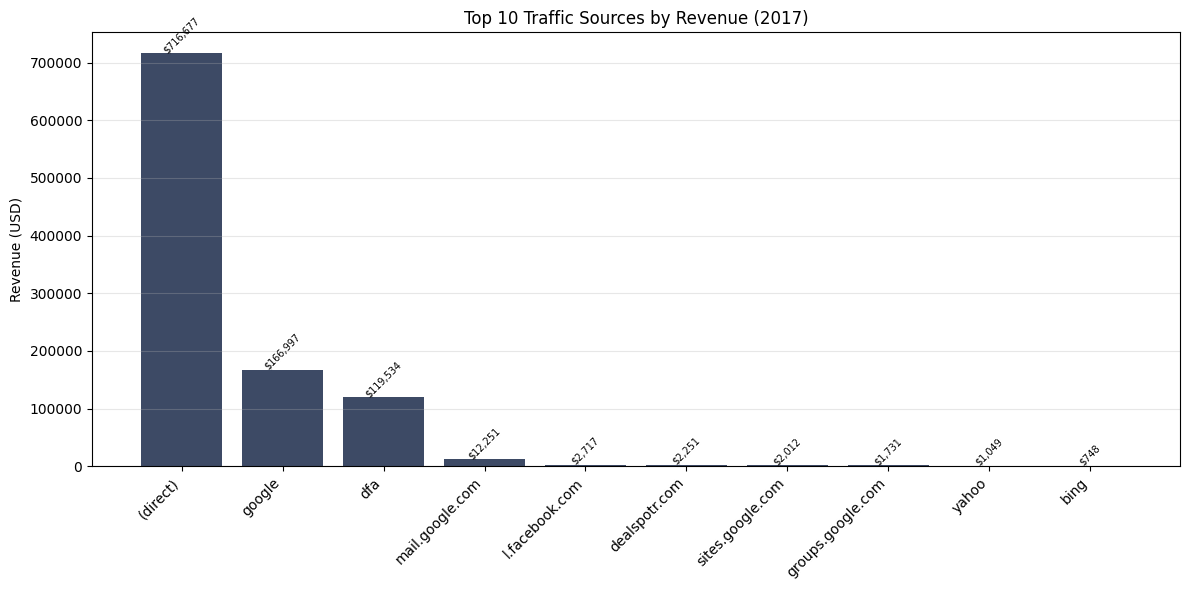


=== TOP 10 SOURCES ===
           source  total_sessions  total_revenue  conversion_rate  revenue_share
         (direct)          189447      716676.81         2.479321      69.652825
           google          179804      166996.95         0.923784      16.230202
              dfa            2728      119533.57         2.639296      11.617302
  mail.google.com             885       12250.64         4.858757       1.190623
   l.facebook.com             572        2717.23         4.720280       0.264084
    dealspotr.com             156        2250.51         7.051282       0.218724
 sites.google.com            1440        2011.92         1.111111       0.195536
groups.google.com             784        1731.48         4.591837       0.168280
            yahoo            1024        1049.15         1.367188       0.101965
             bing            1080         747.77         1.296296       0.072675


In [6]:
# Aggregate by source
source = df.groupby('source').agg(
    total_sessions    = ('sessions', 'sum'),
    total_transactions= ('transactions', 'sum'),
    total_revenue     = ('revenue', 'sum')
).reset_index()

source['conversion_rate'] = (source['total_transactions'] / source['total_sessions']) * 100
source['revenue_share']   = (source['total_revenue'] / source['total_revenue'].sum()) * 100
source = source.sort_values('total_revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(source['source'], source['total_revenue'],
        color='#1B2A4A', alpha=0.85)
plt.title('Top 10 Traffic Sources by Revenue (2017)')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(source['total_revenue']):
    plt.text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=7, rotation=45)
plt.tight_layout()
plt.savefig('../reports/04_top_sources_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 10 SOURCES ===")
print(source[['source','total_sessions','total_revenue',
              'conversion_rate','revenue_share']].to_string(index=False))

## 7. Export Channel Attribution Data for Power BI

In [7]:
# Export all attribution tables
medium.to_csv('../data/exports/channel_by_medium.csv', index=False)
device.to_csv('../data/exports/channel_by_device.csv', index=False)
source.to_csv('../data/exports/channel_by_source.csv', index=False)

print("=== CHANNEL ATTRIBUTION EXPORTS COMPLETE ===")
print("channel_by_medium.csv  → data/exports/")
print("channel_by_device.csv  → data/exports/")
print("channel_by_source.csv  → data/exports/")
print(f"\nMediums tracked:  {len(medium)}")
print(f"Devices tracked:  {len(device)}")
print(f"Top sources:      {len(source)}")

=== CHANNEL ATTRIBUTION EXPORTS COMPLETE ===
channel_by_medium.csv  → data/exports/
channel_by_device.csv  → data/exports/
channel_by_source.csv  → data/exports/

Mediums tracked:  7
Devices tracked:  3
Top sources:      10
